## Meta-Analysis Ranking

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

input  = "/content/spearman.csv"              # wide dataset
output = "/content/spearman_results.csv"      # new output (what the pipeline expects)

col = "depression_status"
drop_col = {"file_name"}

df = pd.read_csv(input)
y = df[col]
y = pd.to_numeric(y)

# Identify feature columns
feature_cols = [c for c in df.columns if c not in ({col} | drop_col)]

# Keep only numeric feature columns
X = df[feature_cols].apply(pd.to_numeric, errors="coerce")

# drop columns that are entirely NaN after coercion
X = X.dropna(axis=1, how="all")

rows = []
y_vals = y.values

#spearman rank correlation analysis and validation
for col in X.columns:
  x_vals = X[col].values
  ok = np.isfinite(x_vals) & np.isfinite(y_vals)
  if ok.sum() < 3:
    continue
  rho, p = spearmanr(x_vals[ok], y_vals[ok])
  if np.isnan(rho):
    continue
  rows.append((col, rho, abs(rho), p, ok.sum()))

#final dataframe with spearman r correlations
out = pd.DataFrame(rows, columns=["feature", "rho", "abs_rho", "p_value", "n_used"])
out = out.sort_values("abs_rho", ascending=False)
out["rank"] = np.arange(1, len(out) + 1)

out.to_csv(output, index=False)
print("Wrote:", output)
print(out.head(10))

Wrote: /content/spearman_results.csv
                                          feature       rho   abs_rho  \
0                            Erucylphosphocholine -0.225547  0.225547   
1                                   PE(15:0/PGJ2) -0.220199  0.220199   
2                    PS(14:0/20:4(5Z,8Z,11Z,14Z)) -0.207513  0.207513   
3                             Hydroxypioglitazone -0.195894  0.195894   
4                            PE(24:0/P-18:1(11Z))  0.193169  0.193169   
5  PG(20:5(7Z,9Z,11E,13E,17Z)-3OH(5,6,15)/a-15:0)  0.193168  0.193168   
6                             DG(15:0/0:0/22:5n3) -0.191812  0.191812   
7                              TG(14:0/16:0/14:0)  0.191543  0.191543   
8    PGP(22:5(4Z,7Z,10Z,13Z,19Z)-O(16,17)/i-20:0) -0.191400  0.191400   
9                          PIP(16:0/18:2(9Z,12Z))  0.191392  0.191392   

    p_value  n_used  rank  
0  0.000191     269     1  
1  0.000273     269     2  
2  0.000615     269     3  
3  0.001241     269     4  
4  0.001455     269

In [ ]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv('shap_values_both_classes.csv', header=[0, 1])

# Get all unique feature names
feature_names = set()
for col in df.columns:
  if 'Unnamed' not in str(col[0]):
    feat = str(col[0]).replace('.1', '')
    feature_names.add(feat)

feature_names = list(feature_names)

# Calculate mean absolute SHAP for each feature
results = []
for feature in feature_names:
  # Find columns for this feature
  shap_values = []
  for col in df.columns:
    col_name = str(col[0])
    if feature in col_name:
    # Get numeric values (skip first row if it contains headers)
    values = df[col].iloc[1:].reset_index(drop=True)
    if len(valid_vals) > 0:
    shap_values.extend(valid_vals)

  #append features to shap_values list
  if len(shap_values) > 0:
    mean_abs_shap = np.mean(shap_values)
    results.append({'feature': feature, 'mean_abs_shap': mean_abs_shap, 'n_values': len(shap_values)})

# Create and save DataFrame
importance_df = pd.DataFrame(results)
importance_df = importance_df.sort_values('mean_abs_shap', ascending=False)

# Save to CSV
importance_df.to_csv('shap_feature_importance.csv', index=False)

print("Top 20 features by mean absolute SHAP value:")
print(importance_df.head(20))
print(f"\nSaved to 'shap_feature_importance.csv'")

Top 20 features by mean absolute SHAP value:
                                            feature  mean_abs_shap  n_values
231                            Erucylphosphocholine       0.034310        38
74                              Hydroxypioglitazone       0.032766        38
145                    Ganglioside GA1 (d18:1/12:0)       0.030744        38
17                       4,6-O-Ethylidene-D-glucose       0.029732        38
53                            Melatonin glucuronide       0.026528        38
13                                     Melledonal C       0.022110        38
193                                   PA(17:0/PGJ2)       0.021590        38
6                                       Grazoprevir       0.021445        38
166                            LS tetrasaccharide d       0.021435        38
104                    PS(14:0/20:4(5Z,8Z,11Z,14Z))       0.020996        38
25                              DG(22:0/0:0/22:5n3)       0.020334        38
176                            

In [ ]:
import pandas as pd
df = pd.read_csv("/content/shap_values_both_classes.csv")
df.head()

,Unnamed: 0,Erucylphosphocholine,Erucylphosphocholine.1,PE(15:0/PGJ2),PE(15:0/PGJ2).1,"PS(14:0/20:4(5Z,8Z,11Z,14Z))","PS(14:0/20:4(5Z,8Z,11Z,14Z)).1",Hydroxypioglitazone,Hydroxypioglitazone.1,PE(24:0/P-18:1(11Z)),...,"3,4,5-Trimethoxyphenyl 2,6-digalloylglucoside","3,4,5-Trimethoxyphenyl 2,6-digalloylglucoside.1",DG(12:0/0:0/PGD1),DG(12:0/0:0/PGD1).1,"4,6-O-Ethylidene-D-glucose","4,6-O-Ethylidene-D-glucose.1",Baloxavir marboxil,Baloxavir marboxil.1,LS tetrasaccharide d,LS tetrasaccharide d.1
0,NaN,Class_0,Class_1,Class_0,Class_1,Class_0,Class_1,Class_0,Class_1,Class_0,...,Class_0,Class_1,Class_0,Class_1,Class_0,Class_1,Class_0,Class_1,Class_0,Class_1
1,Sample_0,-0.1147241909160382,0.0,0.0,0.0,-0.22623600122622317,0.1417990483421212,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Sample_1,0.0,0.0,0.0,0.0,-0.15488041732805194,-0.0031007883035474165,-0.13831193053543017,0.2701341762000488,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Sample_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.41283862744457983,-0.41283862744458005,0.0,0.0,0.0,0.0
4,Sample_3,0.0,0.0,0.0,0.0,0.0,0.0,0.39931746072446267,-0.4038885634289019,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


                                                    SHAP_MLP  PERM_MLP  \
feature                                                                  
Formothion                                          0.927126  0.983806   
Tempo                                               0.987854  0.951417   
CE(PGD1)                                            0.904858  0.991903   
8-[(2R,3S)-3-(8-Hydroxyoctyl)oxiran-2-yl]octano...  0.979757  0.943320   
Vertilmicin                                         0.975709  0.959514   
O‐[(4Z)‐Decenoyl]carnitine                          0.971660  0.939271   
7-Isopropyl-1,4-dimethylazulene                     0.995951  1.000000   
DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)       0.809717  0.987854   
Lotrafiban                                          0.919028  0.979757   
PE(22:4(7Z,10Z,13Z,16Z)/P-18:0)                     0.665992  0.995951   
N-Oxalylglycine                                     0.882591  0.910931   
Dioctyltin isooctylthioglycolate      

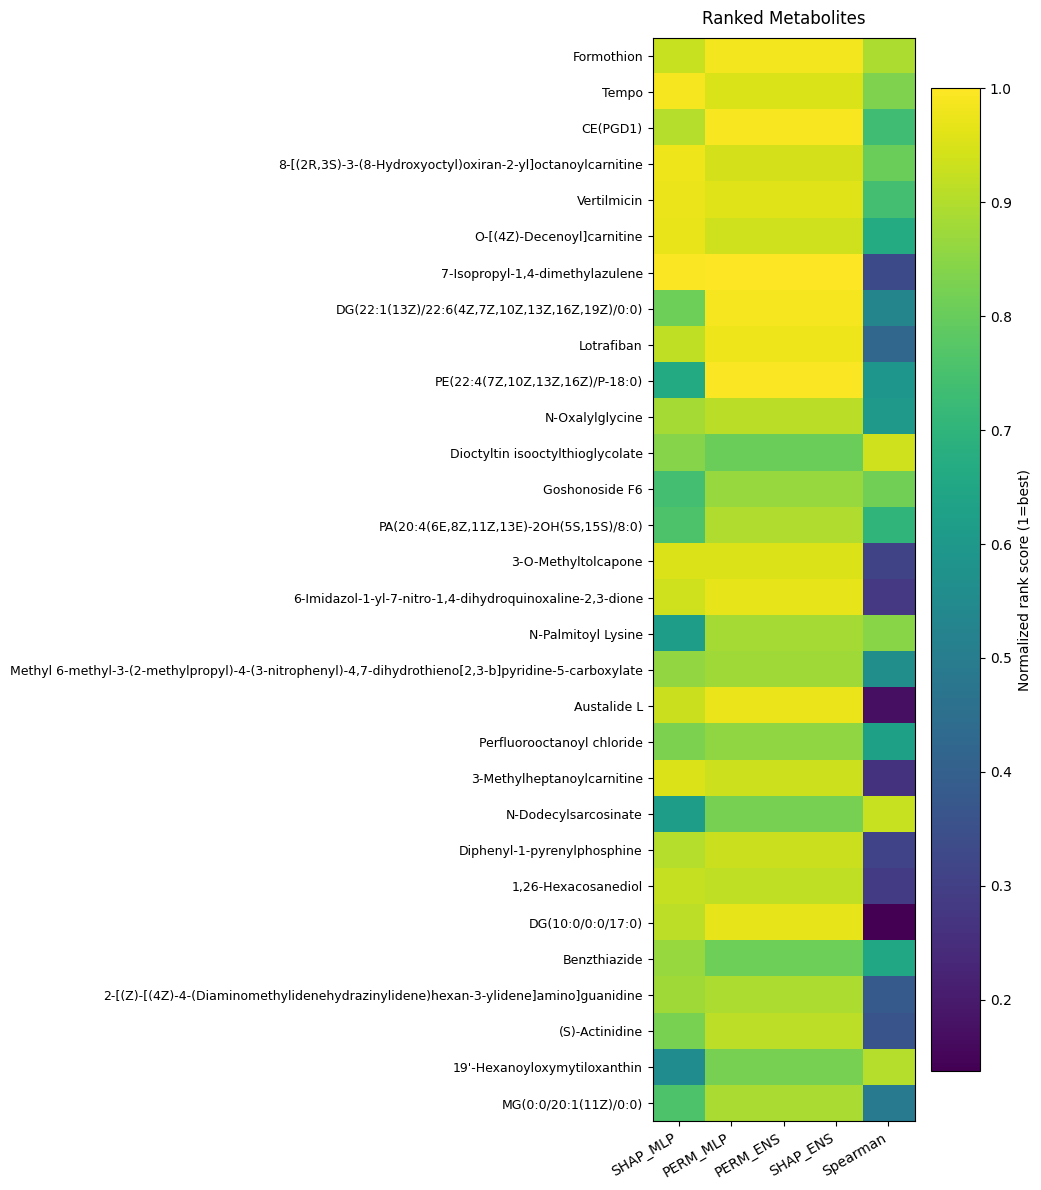

In [ ]:
import matplotlib.pyplot as plt


#Loads CSV containing per-feature scores and returns pandas series
def load_feature_values(csv_path, feature_col="feature", value_col="value"):
  df = pd.read_csv(csv_path)
  s = df[[feature_col, value_col]].dropna()
  s = s.groupby(feature_col)[value_col].mean()  # in case duplicates exist
  return s

#normalizes importance values on [0,1]
def values_to_rank_score(values: pd.Series, higher_is_better=True) -> pd.Series:
  if values.empty:
    return values
  # If lower is better, invert ordering
  ascending = not higher_is_better
  # rank: 1 = best
  ranks = values.rank(ascending=ascending, method="average")
  n = len(ranks)
  if n == 1:
    return pd.Series([1.0], index=ranks.index)
  score = 1.0 - (ranks - 1.0) / (n - 1.0)
  return score

#returns dataframe with normalized rank scores and combined score
def build_combined_table(shap_mlp: pd.Series, perm_mlp: pd.Series, perm_ens: pd.Series, shap_ens: pd.Series, spear: pd.Series, fill_missing_with=0.0, consistency_weight=True,) -> pd.DataFrame:
  df = pd.DataFrame({
    "SHAP_MLP": values_to_rank_score(shap_mlp, higher_is_better=True),
    "PERM_MLP": values_to_rank_score(perm_mlp, higher_is_better=True),
    "PERM_ENS": values_to_rank_score(perm_ens, higher_is_better=True),
    "SHAP_ENS": values_to_rank_score(shap_ens, higher_is_better=True),
    "Spearman": values_to_rank_score(spear, higher_is_better=True),
  }).fillna(fill_missing_with)

  # Presence = how many methods this feature appears in
  presence = (df > 0).sum(axis=1)

  # Combined score: sum across methods
  combined = df.sum(axis=1)
  if consistency_weight:
    combined = combined * (presence / df.shape[1])

  df["Combined"] = combined
  df["Presence"] = presence
  return df


#Plots heatmap of normalized rank scores for each method
def plot_method_heatmap(df: pd.DataFrame, top_n=30, sort_by=("Combined", "Presence"), method_cols=("SHAP_MLP", "PERM_MLP", "PERM_ENS", "SHAP_ENS", "Spearman"), annotate=False, figsize=(10, 12), title="Cross-method metabolite robustness heatmap"):
  # sort_by can be a tuple for multi-key sorting
  df_plot = df.copy()
  sort_cols = list(sort_by) if isinstance(sort_by, (list, tuple)) else [sort_by]
  df_plot = df_plot.sort_values(sort_cols, ascending=False).head(top_n)

  data = df_plot.loc[:, method_cols].to_numpy()
  row_labels = df_plot.index.tolist()
  col_labels = list(method_cols)

  fig, ax = plt.subplots(figsize=figsize)
  im = ax.imshow(data, aspect="auto")

  ax.set_yticks(np.arange(len(row_labels)))
  ax.set_yticklabels(row_labels, fontsize=9)
  ax.set_xticks(np.arange(len(col_labels)))
  ax.set_xticklabels(col_labels, fontsize=10, rotation=30, ha="right")

  ax.set_title(title, fontsize=12, pad=10)
  cbar = fig.colorbar(im, ax=ax)
  cbar.set_label("Normalized rank score (1=best)", rotation=90)

  plt.tight_layout()
  plt.show()

#set up csv paths
PERM_MLP_CSV  = "/content/perm_mlp.csv"
SHAP_MLP_CSV  = "/content/shap_mlp.csv"
SPEARMAN_CSV  = "/content/spearman_results.csv"
SHAP_ENS_CSV = "/content/shap_feature_importance.csv"
PERM_ENS_CSV = "/content/permutation_importance_both_classes.csv"

# Update column names
shap_mlp = load_feature_values(SHAP_MLP_CSV, feature_col="feature", value_col="mean_abs_shap")
perm_mlp = load_feature_values(PERM_MLP_CSV, feature_col="feature", value_col="perm_mean")
shap_ens = load_feature_values(SHAP_ENS_CSV, feature_col="feature", value_col="mean_abs_shap")
perm_ens = load_feature_values(PERM_ENS_CSV, feature_col="feature", value_col="importance_mean")
spearman = load_feature_values(SPEARMAN_CSV, feature_col="feature", value_col="abs_rho")

combined_df = build_combined_table(shap_mlp=shap_mlp, perm_mlp=perm_mlp, perm_ens=perm_ens, shap_ens=shap_ens, spear=spearman, fill_missing_with=0.0, consistency_weight=True, )

# Inspect top features
print(combined_df.sort_values(["Combined", "Presence"], ascending=False).head(15))

# Plot heatmap of top candidates
plot_method_heatmap(combined_df, top_n=30, annotate=False, title="Ranked Metabolites")

## Top Metabolites

In [ ]:
top_feats = combined_df.sort_values("Combined", ascending=False).head(15).index.tolist()

In [ ]:
#function for identifying whether feature is up/down regulated
def cohens_d(x1, x2):
  m1, m2 = np.nanmean(x1), np.nanmean(x2)
  s1, s2 = np.nanstd(x1, ddof=1), np.nanstd(x2, ddof=1)
  n1, n2 = len(x1), len(x2)
  pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
  return (m2 - m1) / pooled  # depression minus control

#running function for each feature in depression and non-depressed patients
rows = []
for f in top_feats:
  ctrl = X.loc[y == 0, f]
  dep  = X.loc[y == 1, f]

  mean_ctrl = ctrl.mean()
  mean_dep  = dep.mean()

  d = cohens_d(ctrl.values, dep.values)
  direction = "↑" if mean_dep > mean_ctrl else "↓"

  rows.append((f, direction, d))

In [ ]:
#printing out final table for top 15
summary = pd.DataFrame(rows, columns=["Metabolite", "Direction", "Effect_Size_Cohen_d"])
summary = summary.sort_values("Effect_Size_Cohen_d", key=abs, ascending=False)
summary = summary.reset_index(drop=True)
summary

,Metabolite,Direction,Effect_Size_Cohen_d
0,Dioctyltin isooctylthioglycolate,↑,0.416114
1,CE(PGD1),↓,-0.276509
2,"DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)",↓,-0.276370
3,Formothion,↑,0.270786
4,Vertilmicin,↓,-0.203830
5,3-O-Methyltolcapone,↓,-0.198800
6,"PE(22:4(7Z,10Z,13Z,16Z)/P-18:0)",↓,-0.192550
7,"PA(20:4(6E,8Z,11Z,13E)-2OH(5S,15S)/8:0)",↓,-0.149264
8,Goshonoside F6,↓,-0.149247
9,Lotrafiban,↓,-0.124598


In [ ]:
#renaming columns
rename_map = {}
for c in summary.columns:
  c_clean = c.strip()
  if c_clean == "Effect_Size_Cohen_d":
    rename_map[c] = "Effect Size (Cohen's d)"
  elif c_clean == "Direction":
    rename_map[c] = "Direction in Depression"

#reseting index and styling column head
summary_pretty = summary.rename(columns=rename_map).copy()
summary_pretty = summary_pretty.reset_index(drop=True)
summary_pretty["Effect Size (Cohen's d)"] = (pd.to_numeric(summary_pretty["Effect Size (Cohen's d)"], errors="coerce").round(3))

# Making the table look prettier
subset_met = ["Metabolite"] if "Metabolite" in summary_pretty.columns else []
subset_dir = ["Direction in Depression"] if "Direction in Depression" in summary_pretty.columns else []
subset_eff = ["Effect Size (Cohen's d)"] if "Effect Size (Cohen's d)" in summary_pretty.columns else []

styled = (summary_pretty.style
  .hide(axis="index")
  .set_properties(subset=subset_met, **{
    "text-align": "center",
    "font-weight": "bold",
    "white-space": "normal"
  })
  .set_properties(subset=subset_eff, **{"text-align": "center"})
  .set_properties(subset=subset_dir, **{"text-align": "center"})
  .set_table_styles([
    {"selector": "table", "props": [
      ("border-collapse", "collapse"),
      ("border", "2px solid black"),
      ("width", "100%")
    ]},
    {"selector": "th", "props": [
      ("text-align", "center"),
      ("font-size", "14px"),
      ("font-weight", "bold"),
      ("background-color", "#f0f0f0"),
      ("border", "1px solid black"),
      ("padding", "8px")
    ]},
    {"selector": "td", "props": [
      ("font-size", "13px"),
      ("border", "1px solid black"),
      ("padding", "8px"),
      ("vertical-align", "middle")
    ]},
  ])
)

styled

Metabolite,Direction in Depression,Effect Size (Cohen's d)
Dioctyltin isooctylthioglycolate,↑,0.416000
CE(PGD1),↓,-0.277000
"DG(22:1(13Z)/22:6(4Z,7Z,10Z,13Z,16Z,19Z)/0:0)",↓,-0.276000
Formothion,↑,0.271000
Vertilmicin,↓,-0.204000
3-O-Methyltolcapone,↓,-0.199000
"PE(22:4(7Z,10Z,13Z,16Z)/P-18:0)",↓,-0.193000
"PA(20:4(6E,8Z,11Z,13E)-2OH(5S,15S)/8:0)",↓,-0.149000
Goshonoside F6,↓,-0.149000
Lotrafiban,↓,-0.125000
